# Hazard assessment for heavy snowfall & blizzards — Kazakhstan

Adapted from the CLIMAAX [Handbook](https://handbook.climaax.eu/) SNOW workflow
for Kazakhstan using globally available datasets.

## Data Substitutions

| Original CLIMAAX (EU) | Kazakhstan Adaptation | Notes |
|---|---|---|
| EURO-CORDEX (Copernicus CDS, EUR-11, 0.11°) | ISIMIP3b bias-adjusted GCMs (direct HTTPS, global, 0.5°) | EURO-CORDEX covers Europe only |
| Rotated-pole grid (rlat/rlon, pyproj) | Regular WGS84 lat/lon | ISIMIP3b uses a standard grid; all rotated-pole code removed |
| RCP 2.6 / 4.5 / 8.5 scenarios | ssp126 (≈RCP2.6) / ssp370 (≈RCP7.0) | Closest CMIP6 SSP equivalents |
| GCM+RCM pairs (e.g. NorESM1-M + SMHI-RCA4) | Single CMIP6 GCMs (e.g. GFDL-ESM4) | ISIMIP3b applies bias-adjustment directly |
| ERA5 bounding box: Europe [80, -10, 20, 45] | ERA5 bounding box: Kazakhstan [57, 45, 39, 88] | Same ERA5 data source, Kazakhstan extent |
| NUTS admin boundaries | Kazakhstan OSM shapefiles (LVL3 dissolved to national) | EU-specific admin system not applicable |
| Orthographic projection centred on Europe | PlateCarree with Kazakhstan extent | Geographic adaptation |

**Methodology preserved (no changes from original):**
- Snow depth (ISIMIP3b / CORDEX branch): `snow_depth_cm = pr_mm_day × 10` when `tas < 2°C`
- Snow depth (ERA5 branch): `snow_depth_cm = (1000 × sd_mwe / rsn_kg_m3) × 100`
- Blizzard indicator: `tas < 0°C  AND  snow_depth > 10 cm  AND  sfcwind > 17 m/s`
- Heavy snow indicators: `snow_depth > 6 cm` and `snow_depth > 25 cm`
- Annual probability: `(days_with_event / total_days_in_year) × 100`

**Note — ERA5:** Requires a Copernicus CDS account and `~/.cdsapirc` key file.
See https://cds.climate.copernicus.eu/how-to-api for setup instructions.

**Bug fix vs. original:** The original ERA5 `year` range used `range(start, end)` which
silently dropped the final year. Fixed here to `range(start, end + 1)`.

In [20]:
import warnings
warnings.filterwarnings("ignore")

import os
import zipfile
from pathlib import Path

import requests
import numpy as np
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cdsapi

## Configuration

In [21]:
# ---- Bounding box (Kazakhstan) ----
lat_north = 57.0
lat_south = 39.0
lon_west  = 45.0   # ~1° buffer west of actual KZ extent (~46.5°E)
lon_east  = 88.0

region_name = 'Kazakhstan'
region_id   = 'KAZ'

# ERA5 area parameter: [N, W, S, E] — CDS API convention
era5_area = [lat_north, lon_west, lat_south, lon_east]

# ---- Time periods ----
# NOTE: 5-year windows match the original notebook's demonstration period.
# For climatological robustness, use 30-year periods (e.g. 1991-2020, 2041-2070).
hist_start_year = 1991
hist_end_year   = 1995

fut_start_year  = 2046
fut_end_year    = 2050

gcm_models = [
    'GFDL-ESM4',
    'IPSL-CM6A-LR',
    'MPI-ESM1-2-HR',
    'MRI-ESM2-0',
    'UKESM1-0-LL',
]
gcm_choice   = 0
gcm_model    = gcm_models[gcm_choice]
ssp_scenario = 'ssp370'

MODEL_ENSEMBLE = {
    'GFDL-ESM4':       'r1i1p1f1',
    'IPSL-CM6A-LR':    'r1i1p1f1',
    'MPI-ESM1-2-HR':   'r1i1p1f1',
    'MRI-ESM2-0':      'r1i1p1f1',
    'UKESM1-0-LL':     'r1i1p1f1',
}

isimip_base = (
    'https://files.isimip.org/ISIMIP3b/InputData/'
    'climate/atmosphere/bias-adjusted/global/daily'
)

# ---- Thresholds — identical to original CLIMAAX SNOW workflow ----
snow_temp_thr = 2.0   # °C — precipitation treated as snow below this temperature
lim_tas       = 0.0   # °C — blizzard temperature threshold
lim_snow10    = 10.0  # cm — blizzard snow depth threshold
lim_gust      = 17.0  # m/s — blizzard wind speed threshold (sfcwind mean, ISIMIP3b branch)
lim_snow6     = 6.0   # cm — moderate heavy snow threshold
lim_snow25    = 25.0  # cm — severe heavy snow threshold

# ---- Directory paths ----
work_dir = Path('SNOW_hazard')
data_dir = work_dir / f'data_{region_id}'
plot_dir = work_dir / f'plots_{region_id}'
# Shapefile: LVL3 districts dissolved to national boundary (adjust depth if needed)
shp_path = Path(r'C:\Users\dauzo\Models\crabook-kazakhstan\crabook\KAZ_BORDER_VERSION_1\LVL3\SHP_LVL3\KAZ_OSM_BORDER_LVL3.shp')
for d in [data_dir, plot_dir]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Model     : {gcm_model}")
print(f"Scenario  : {ssp_scenario}")
print(f"Historical: {hist_start_year}–{hist_end_year}")
print(f"Future    : {fut_start_year}–{fut_end_year}")

Model     : GFDL-ESM4
Scenario  : ssp370
Historical: 1991–1995
Future    : 2046–2050


## ISIMIP3b data download helpers

ISIMIP3b stores bias-adjusted daily data in 10-year files.  
Decade boundaries: 1991–2000, 2001–2010, 2041–2050, etc.  
No API key required — data are freely accessible via HTTPS.

In [22]:
def isimip3b_decade_bounds(year):
    """
    Return (start_year_str, end_year_str) for the ISIMIP3b decade file
    containing `year`.  Example: year=1993 → ('1991', '2000').
    ISIMIP3b filenames use YYYY_YYYY format, not YYYYMMDD_YYYYMMDD.
    """
    d_start = ((year - 1) // 10) * 10 + 1
    d_end   = d_start + 9
    return str(d_start), str(d_end)


def get_decades_for_range(start_year, end_year):
    """Return list of (d_start_str, d_end_str) covering all of [start_year, end_year]."""
    decades, y = [], start_year
    while y <= end_year:
        s, e = isimip3b_decade_bounds(y)
        if (s, e) not in decades:
            decades.append((s, e))
        y = int(e) + 1   # e is now 'YYYY', not 'YYYYMMDD'
    return decades


def download_isimip3b(variable, scenario, gcm, d_start, d_end, dest_dir):
    """
    Download one ISIMIP3b NetCDF file; skip if already present (cache pattern).
    variable : all-lowercase filename convention, e.g. 'tas', 'pr', 'sfcwind'
    """
    # ISIMIP3b filename convention: YYYY_YYYY decade format (not YYYYMMDD)
    ensemble  = MODEL_ENSEMBLE[gcm]
    gcm_lower = gcm.lower()
    gcm_dir   = gcm.upper()
    fname = f'{gcm_lower}_{ensemble}_w5e5_{scenario}_{variable}_global_daily_{d_start}_{d_end}.nc'
    fpath = dest_dir / fname
    if fpath.exists():
        print(f'  Cached: {fname}')
        return fpath
    url = f'{isimip_base}/{scenario}/{gcm_dir}/{fname}'
    print(f'  Downloading: {fname}')
    with requests.get(url, stream=True, timeout=600) as r:
        r.raise_for_status()
        total = int(r.headers.get('content-length', 0))
        downloaded = 0
        with open(fpath, 'wb') as f:
            for chunk in r.iter_content(chunk_size=65536):
                f.write(chunk)
                downloaded += len(chunk)
                if total:
                    print(f'\r    {downloaded / total * 100:.1f}%', end='', flush=True)
    print()
    return fpath


def load_and_clip(fpath, lat_s, lat_n, lon_w, lon_e, yr_start=None, yr_end=None):
    """
    Open an ISIMIP3b file, sort lat (may be descending), clip to bbox,
    optionally subset to [yr_start, yr_end].
    """
    ds = xr.open_dataset(fpath, chunks='auto')
    ds = ds.sortby('lat').sortby('lon')
    # Small buffer so boundary grid cells are captured
    ds = ds.sel(lat=slice(lat_s - 0.25, lat_n + 0.25),
                lon=slice(lon_w - 0.25, lon_e + 0.25))
    if yr_start is not None:
        ds = ds.sel(time=slice(str(yr_start), str(yr_end)))
    return ds


def get_main_var(ds):
    """Return the first non-auxiliary data variable name."""
    skip = {'time_bnds', 'lat_bnds', 'lon_bnds', 'time_bounds'}
    return next(v for v in ds.data_vars if v not in skip)

### Download ISIMIP3b historical data (tas, pr, sfcwind)

In [23]:
hist_decades = get_decades_for_range(hist_start_year, hist_end_year)
print(f'Historical decades needed: {hist_decades}')

hist_files = {}
for var in ['tas', 'pr', 'sfcwind']:
    hist_files[var] = [
        download_isimip3b(var, 'historical', gcm_model, ds, de, data_dir)
        for ds, de in hist_decades
    ]


def load_variable(files, yr_start, yr_end):
    """Load, clip, and concat files; subset to [yr_start, yr_end]."""
    if len(files) == 1:
        return load_and_clip(files[0], lat_south, lat_north, lon_west, lon_east,
                             yr_start, yr_end)
    dsets = [load_and_clip(f, lat_south, lat_north, lon_west, lon_east) for f in files]
    ds    = xr.concat(dsets, dim='time').sortby('time')
    return ds.sel(time=slice(str(yr_start), str(yr_end)))


pr_hist_ds   = load_variable(hist_files['pr'],     hist_start_year, hist_end_year)
tas_hist_ds  = load_variable(hist_files['tas'],    hist_start_year, hist_end_year)
wind_hist_ds = load_variable(hist_files['sfcwind'], hist_start_year, hist_end_year)

# Detect actual NetCDF variable names (filename uses lowercase; internal name may differ)
pr_var   = get_main_var(pr_hist_ds)
tas_var  = get_main_var(tas_hist_ds)
wind_var = get_main_var(wind_hist_ds)
print(f"Variable names — pr: '{pr_var}', tas: '{tas_var}', wind: '{wind_var}'")

Historical decades needed: [('1991', '2000')]
  Cached: gfdl-esm4_r1i1p1f1_w5e5_historical_tas_global_daily_1991_2000.nc
  Cached: gfdl-esm4_r1i1p1f1_w5e5_historical_pr_global_daily_1991_2000.nc
  Cached: gfdl-esm4_r1i1p1f1_w5e5_historical_sfcwind_global_daily_1991_2000.nc
Variable names — pr: 'pr', tas: 'tas', wind: 'sfcwind'


### Download ISIMIP3b SSP future data

In [24]:
fut_decades = get_decades_for_range(fut_start_year, fut_end_year)
print(f'Future decades needed: {fut_decades}')

fut_files = {}
for var in ['tas', 'pr', 'sfcwind']:
    fut_files[var] = [
        download_isimip3b(var, ssp_scenario, gcm_model, ds, de, data_dir)
        for ds, de in fut_decades
    ]

pr_fut_ds   = load_variable(fut_files['pr'],     fut_start_year, fut_end_year)
tas_fut_ds  = load_variable(fut_files['tas'],    fut_start_year, fut_end_year)
wind_fut_ds = load_variable(fut_files['sfcwind'], fut_start_year, fut_end_year)

Future decades needed: [('2041', '2050')]
  Cached: gfdl-esm4_r1i1p1f1_w5e5_ssp370_tas_global_daily_2041_2050.nc
  Cached: gfdl-esm4_r1i1p1f1_w5e5_ssp370_pr_global_daily_2041_2050.nc
  Cached: gfdl-esm4_r1i1p1f1_w5e5_ssp370_sfcwind_global_daily_2041_2050.nc


## Process ISIMIP3b data

### Unit conversions — identical to the EURO-CORDEX branch of the original workflow

- Temperature: K → °C  (−273.15)
- Precipitation: kg m⁻² s⁻¹ → mm day⁻¹  (×86 400)
- Wind speed: m s⁻¹, no conversion needed
- Snow depth: `pr_mm × 10` when `tas < 2°C`, else 0  (same approximation as CORDEX branch)

In [25]:
# ---- Historical ----
pr_hist_mmday = pr_hist_ds[pr_var]    * 86400.0   # mm/day
tas_hist_C    = tas_hist_ds[tas_var]  - 273.15    # °C
wind_hist_ms  = wind_hist_ds[wind_var]             # m/s — no conversion

snow_con_hist   = tas_hist_C < snow_temp_thr
snow_depth_hist = xr.where(snow_con_hist, pr_hist_mmday * 10.0, 0.0)
snow_depth_hist.attrs.update({'units': 'cm', 'long_name': 'Estimated snow depth'})
snow_depth_hist.name = 'snow_depth'

# ---- Future ----
pr_fut_mmday = pr_fut_ds[pr_var]    * 86400.0
tas_fut_C    = tas_fut_ds[tas_var]  - 273.15
wind_fut_ms  = wind_fut_ds[wind_var]

snow_con_fut   = tas_fut_C < snow_temp_thr
snow_depth_fut = xr.where(snow_con_fut, pr_fut_mmday * 10.0, 0.0)
snow_depth_fut.attrs.update({'units': 'cm', 'long_name': 'Estimated snow depth'})
snow_depth_fut.name = 'snow_depth'

### Calculate annual probability indicators — ISIMIP3b

In [26]:
def calc_annual_prob(condition_da, total_days_yr, var_name, long_name):
    """
    Calculate annual probability (%) of a boolean condition DataArray,
    mask out zeros, return (annual DataArray, multi-year mean DataArray).
    Uses multiplication of boolean arrays, consistent with original CLIMAAX workflow.
    """
    count = condition_da.groupby('time.year').sum('time')
    prob  = (count / total_days_yr) * 100.0
    prob  = prob.where(prob != 0.)
    prob.attrs = {'units': '%', 'long_name': long_name}
    prob.name  = var_name
    return prob, prob.mean('year')


total_days_hist = snow_depth_hist.groupby('time.year').count(dim='time')
total_days_fut  = snow_depth_fut.groupby('time.year').count(dim='time')

# ---- Historical ----
blizzard_cond_hist = (
    (tas_hist_C < lim_tas)
    * (snow_depth_hist > lim_snow10)
    * (wind_hist_ms > lim_gust)
)
blizzard_hist,  blizzard_hist_mean  = calc_annual_prob(
    blizzard_cond_hist, total_days_hist, 'blizzard_days',
    'Annual probability of blizzard days')

snow6_hist,     snow6_hist_mean     = calc_annual_prob(
    snow_depth_hist > lim_snow6,  total_days_hist, 'snow_days',
    'Annual probability of snowfall > 6 cm days')

snow25_hist,    snow25_hist_mean    = calc_annual_prob(
    snow_depth_hist > lim_snow25, total_days_hist, 'snow_days',
    'Annual probability of snowfall > 25 cm days')

for _f in [
    data_dir / f'BdayCount_AnaProb_mean_{gcm_model}_historical_{hist_start_year}_{hist_end_year}.nc',
    data_dir / f'Snow6Prob_annual_mean_{gcm_model}_historical_{hist_start_year}_{hist_end_year}.nc',
    data_dir / f'Snow25Prob_annual_mean_{gcm_model}_historical_{hist_start_year}_{hist_end_year}.nc',
]:
    if _f.exists(): _f.unlink()

blizzard_hist_mean.load().to_netcdf(
    data_dir / f'BdayCount_AnaProb_mean_{gcm_model}_historical_{hist_start_year}_{hist_end_year}.nc')
snow6_hist_mean.load().to_netcdf(
    data_dir / f'Snow6Prob_annual_mean_{gcm_model}_historical_{hist_start_year}_{hist_end_year}.nc')
snow25_hist_mean.load().to_netcdf(
    data_dir / f'Snow25Prob_annual_mean_{gcm_model}_historical_{hist_start_year}_{hist_end_year}.nc')
print('ISIMIP3b historical indicators saved.')

# ---- Future ----
blizzard_cond_fut = (
    (tas_fut_C < lim_tas)
    * (snow_depth_fut > lim_snow10)
    * (wind_fut_ms > lim_gust)
)
blizzard_fut,   blizzard_fut_mean   = calc_annual_prob(
    blizzard_cond_fut, total_days_fut, 'blizzard_days',
    'Annual probability of blizzard days')

snow6_fut,      snow6_fut_mean      = calc_annual_prob(
    snow_depth_fut > lim_snow6,  total_days_fut, 'snow_days',
    'Annual probability of snowfall > 6 cm days')

snow25_fut,     snow25_fut_mean     = calc_annual_prob(
    snow_depth_fut > lim_snow25, total_days_fut, 'snow_days',
    'Annual probability of snowfall > 25 cm days')

for _f in [
    data_dir / f'BdayCount_AnaProb_mean_{gcm_model}_{ssp_scenario}_{fut_start_year}_{fut_end_year}.nc',
    data_dir / f'Snow6Prob_annual_mean_{gcm_model}_{ssp_scenario}_{fut_start_year}_{fut_end_year}.nc',
    data_dir / f'Snow25Prob_annual_mean_{gcm_model}_{ssp_scenario}_{fut_start_year}_{fut_end_year}.nc',
]:
    if _f.exists(): _f.unlink()

blizzard_fut_mean.load().to_netcdf(
    data_dir / f'BdayCount_AnaProb_mean_{gcm_model}_{ssp_scenario}_{fut_start_year}_{fut_end_year}.nc')
snow6_fut_mean.load().to_netcdf(
    data_dir / f'Snow6Prob_annual_mean_{gcm_model}_{ssp_scenario}_{fut_start_year}_{fut_end_year}.nc')
snow25_fut_mean.load().to_netcdf(
    data_dir / f'Snow25Prob_annual_mean_{gcm_model}_{ssp_scenario}_{fut_start_year}_{fut_end_year}.nc')
print('ISIMIP3b future indicators saved.')

ISIMIP3b historical indicators saved.
ISIMIP3b future indicators saved.


## Download ERA5 reanalysis data

ERA5 serves as the observational reference baseline, identical in structure to
the original CLIMAAX workflow.  Only the bounding box has changed (Kazakhstan).

Variables (same as original):
- `2m_temperature` → `t2m` (K)
- `10m_wind_gust_since_previous_post_processing` → `fg10` (m s⁻¹)
- `snow_depth` → `sd` (m of water equivalent)
- `snow_density` → `rsn` (kg m⁻³)

**Bug fix vs. original:** `range(start, end)` silently dropped the final year;
corrected to `range(start, end + 1)`.

In [27]:
URL = 'https://cds.climate.copernicus.eu/api'
KEY = None  # add your key here if not using ~/.cdsapirc

c = cdsapi.Client(url=URL, key=KEY)

era5_dir = data_dir / f'ERA5_data_{hist_start_year}_{hist_end_year}'

era5_dir.mkdir(parents=True, exist_ok=True)

years_needed = [
    y for y in range(hist_start_year, hist_end_year + 1)
    if not any(era5_dir.glob(f'era5_{y}_*.nc'))
]

if not years_needed:
    print('All ERA5 years cached — skipping CDS client init')

for year in range(hist_start_year, hist_end_year + 1):
    if any(era5_dir.glob(f'era5_{year}_*.nc')):
        print(f'  Cached: ERA5 {year}')
        continue
    era5_zip_yr = era5_dir / f'era5_{year}.zip'
    print(f'  Downloading ERA5 {year}...')
    c.retrieve(
        'reanalysis-era5-single-levels',
        {
            'data_format': 'netcdf',
            'download_format': 'zip',
            'product_type': 'reanalysis',
            'variable': [
                '2m_temperature',
                '10m_wind_gust_since_previous_post_processing',
                'snow_depth',
                'snow_density',
            ],
            'year': [str(year)],
            'month': [f'{m:02d}' for m in range(1, 13)],
            'time': ['00:00', '06:00', '12:00', '18:00'],
            'day': [f'{d:02d}' for d in range(1, 32)],
            'grid': [0.25, 0.25],
            'area': era5_area,
        },
        str(era5_zip_yr),
    )

    with zipfile.ZipFile(era5_zip_yr, 'r') as z:
        for i, n in enumerate(z.namelist()):
            if Path(n).suffix == '.nc':
                target = era5_dir / f'era5_{year}_{i}.nc'
                target.write_bytes(z.read(n))
    era5_zip_yr.unlink()
    print(f'  Saved ERA5 {year} files.')

print(f'ERA5 ready in {era5_dir}')

All ERA5 years cached — skipping CDS client init
  Cached: ERA5 1991
  Cached: ERA5 1992
  Cached: ERA5 1993
  Cached: ERA5 1994
  Cached: ERA5 1995
ERA5 ready in SNOW_hazard\data_KAZ\ERA5_data_1991_1995


## Process ERA5 data

Identical to the original CLIMAAX workflow.

Unit conversions (unchanged):
- Temperature: K → °C
- Snow depth: `snow_depth_cm = (1000 × sd_mwe / rsn_kg_m3) × 100`  
  Guard added for rsn = 0 (no-snow cells) to prevent division-by-zero NaN.
- Wind: already m s⁻¹, no conversion

In [28]:
ds_era5 = xr.open_mfdataset(str(era5_dir / '*.nc'), chunks='auto')

# Recent CDS API versions name the time coordinate 'valid_time'
if 'valid_time' in ds_era5.coords:
    ds_era5 = ds_era5.rename({'valid_time': 'time'})
if 'number' in ds_era5:
    ds_era5 = ds_era5.drop_vars('number')

# Temperature: K → °C
ds_era5['t2m'] = ds_era5['t2m'] - 273.15
ds_era5['t2m'].attrs['units'] = 'degC'

# Snow depth (cm): guard rsn=0 to avoid NaN in snow-free cells
ds_era5['snow_depth'] = xr.where(
    ds_era5.rsn > 0,
    (1000.0 * ds_era5.sd / ds_era5.rsn) * 100.0,
    0.0
)
ds_era5['snow_depth'].attrs.update({'units': 'cm', 'description': 'snow depth'})
ds_era5 = ds_era5.drop_vars(['sd', 'rsn'])

# Shift time axis — ERA5 accumulation convention (unchanged from original)
ds_era5 = ds_era5.shift(time=1)

# Resample to daily
tas_day_era5  = ds_era5.t2m.resample(time='24h').mean('time')
wspd_day_era5 = ds_era5.fg10.resample(time='24h').max('time')
snow_day_era5 = ds_era5.snow_depth.resample(time='24h').mean('time')

### Calculate annual probability indicators — ERA5

In [29]:
total_days_era5 = snow_day_era5.groupby('time.year').count(dim='time')

# Blizzard days
BdayCount_era5 = (
    (tas_day_era5 < lim_tas)
    * (snow_day_era5 > lim_snow10)
    * (wspd_day_era5 > lim_gust)
).groupby('time.year').sum('time')
blizzard_prob_era5       = (BdayCount_era5 / total_days_era5) * 100.0
blizzard_prob_era5       = blizzard_prob_era5.where(blizzard_prob_era5 != 0.)
blizzard_prob_era5.attrs = {'units': '%', 'long_name': 'Annual probability of blizzard days'}
blizzard_mean_era5       = blizzard_prob_era5.mean('year').to_dataset(name='blizzard_days')
blizzard_mean_era5.to_netcdf(
    data_dir / f'BdayCount_AnaProb_mean_ERA5_{hist_start_year}_{hist_end_year}.nc')

# Snow > 6 cm
snow6_prob_era5      = ((snow_day_era5 > lim_snow6).groupby('time.year').sum('time')
                        / total_days_era5) * 100.0
snow6_prob_era5      = snow6_prob_era5.where(snow6_prob_era5 != 0.)
snow6_prob_era5.attrs = {'units': '%', 'long_name': 'Annual probability of snowfall > 6 cm'}
snow6_mean_era5      = snow6_prob_era5.mean('year').to_dataset(name='snow_days')
snow6_mean_era5.to_netcdf(
    data_dir / f'Snow6Prob_annual_mean_ERA5_{hist_start_year}_{hist_end_year}.nc')

# Snow > 25 cm
snow25_prob_era5      = ((snow_day_era5 > lim_snow25).groupby('time.year').sum('time')
                         / total_days_era5) * 100.0
snow25_prob_era5      = snow25_prob_era5.where(snow25_prob_era5 != 0.)
snow25_prob_era5.attrs = {'units': '%', 'long_name': 'Annual probability of snowfall > 25 cm'}
snow25_mean_era5      = snow25_prob_era5.mean('year').to_dataset(name='snow_days')
snow25_mean_era5.to_netcdf(
    data_dir / f'Snow25Prob_annual_mean_ERA5_{hist_start_year}_{hist_end_year}.nc')

print('ERA5 indicators saved.')

ERA5 indicators saved.


## Load Kazakhstan boundary shapefile

In [30]:
kz_gdf = gpd.read_file(shp_path)
if kz_gdf.crs is None or kz_gdf.crs.to_epsg() != 4326:
    kz_gdf = kz_gdf.to_crs(epsg=4326)
# Dissolve to a single national boundary polygon for clean overlay
kz_national = kz_gdf.dissolve()
print(f'KZ shapefile loaded: {len(kz_gdf)} feature(s) → dissolved to national boundary')

KZ shapefile loaded: 227 feature(s) → dissolved to national boundary


## Visualize hazard indicators

Six plots mirroring the original CLIMAAX SNOW structure:
1. Blizzard probability — ERA5 (observational reference)
2. Blizzard probability — ISIMIP3b historical (replaces CORDEX historical)
3. Snow > 6 cm probability — ERA5
4. Snow > 6 cm probability — ISIMIP3b historical
5. Snow > 25 cm probability — ERA5
6. Snow > 25 cm probability — ISIMIP3b historical

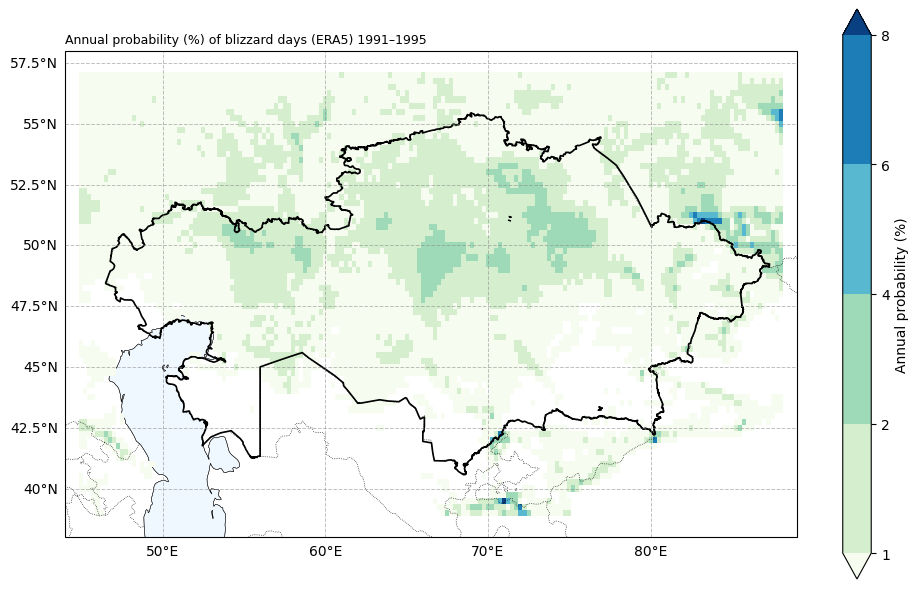

Saved: SNOW_hazard\plots_KAZ\blizzard_prob_ERA5_1991_1995.png


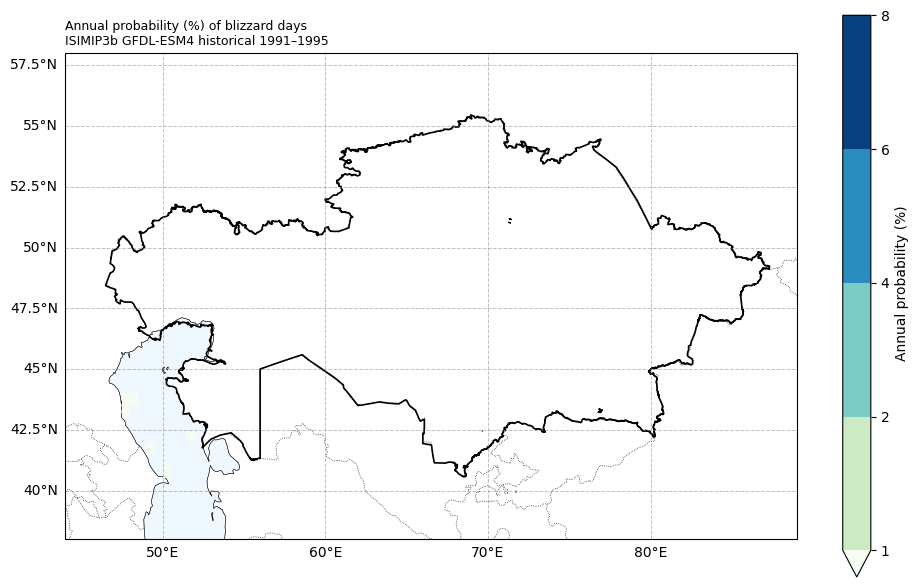

Saved: SNOW_hazard\plots_KAZ\blizzard_prob_GFDL-ESM4_historical_1991_1995.png


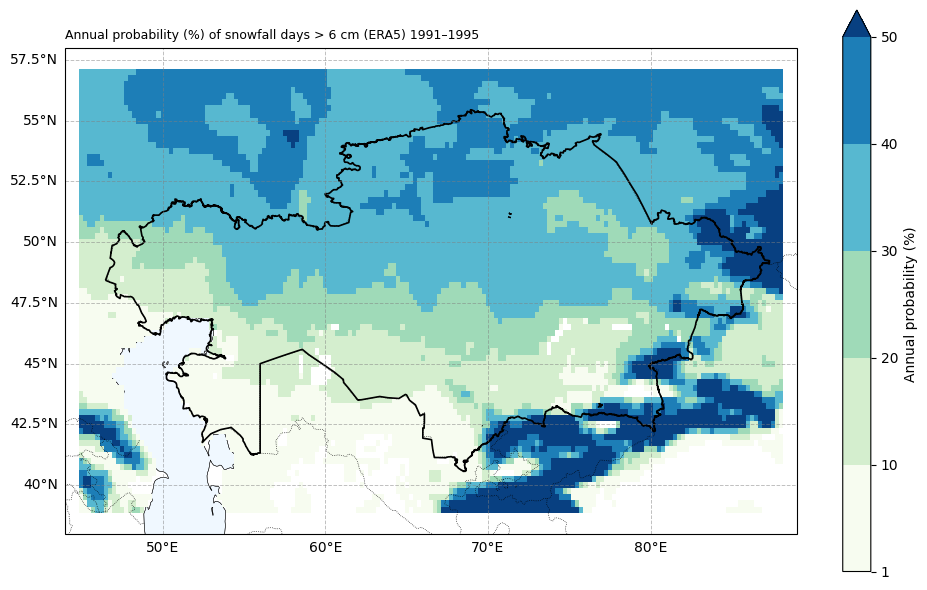

Saved: SNOW_hazard\plots_KAZ\snow6cm_prob_ERA5_1991_1995.png


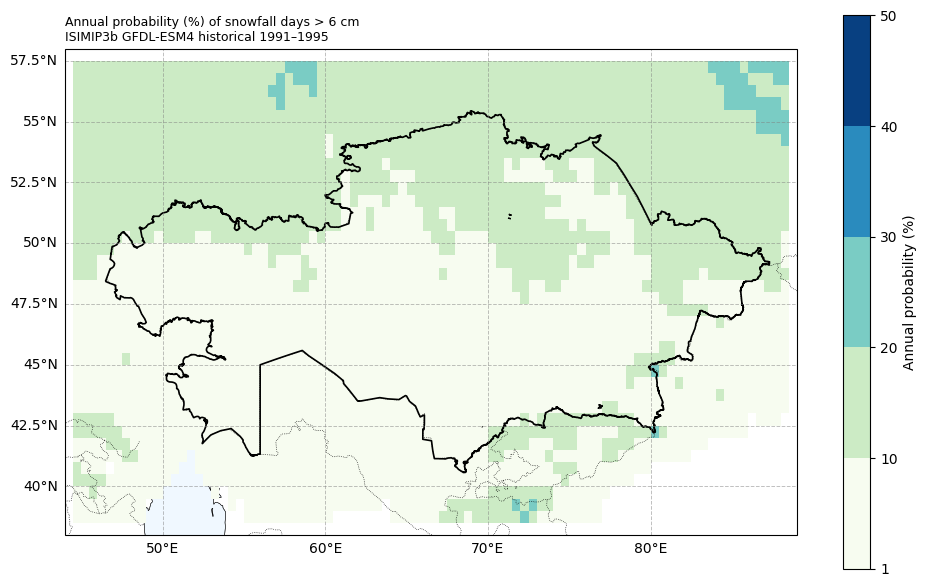

Saved: SNOW_hazard\plots_KAZ\snow6cm_prob_GFDL-ESM4_historical_1991_1995.png


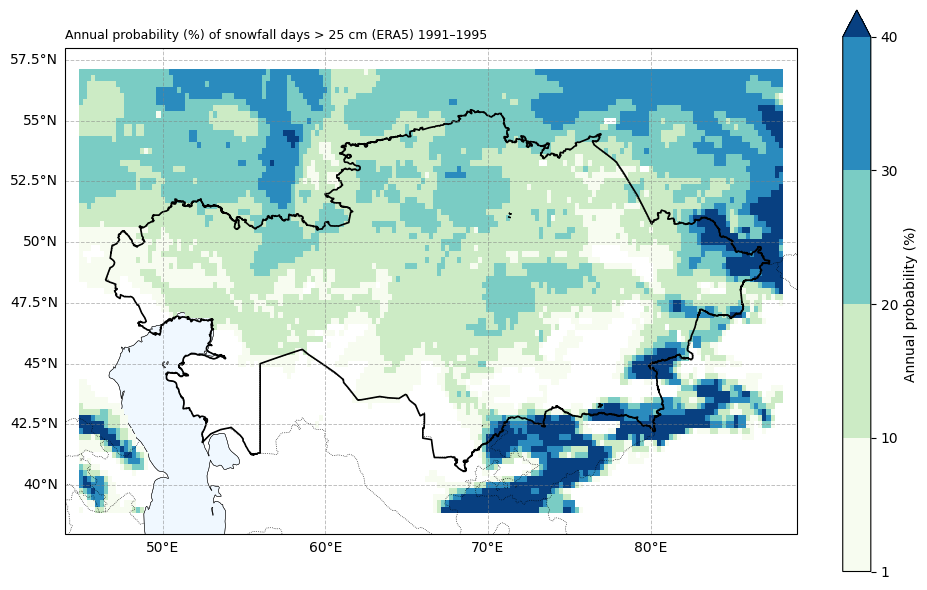

Saved: SNOW_hazard\plots_KAZ\snow25cm_prob_ERA5_1991_1995.png


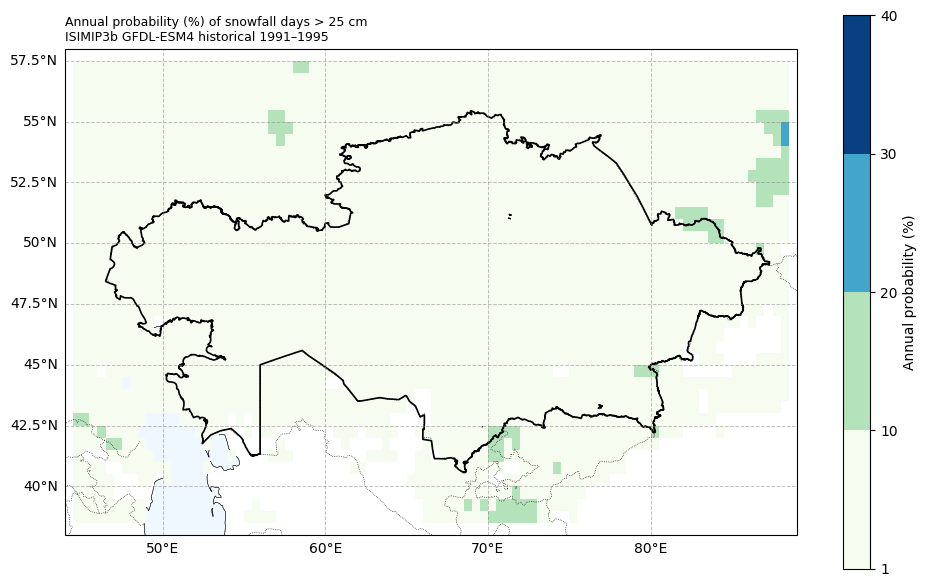

Saved: SNOW_hazard\plots_KAZ\snow25cm_prob_GFDL-ESM4_historical_1991_1995.png
All plots saved.


In [31]:
def make_kz_plot(data_da, title, p_levels, cmap, outfile, kz_national):
    """
    Produce a Kazakhstan hazard probability map.
    Handles both ERA5 (latitude/longitude coords) and ISIMIP3b (lat/lon coords).
    """
    fig, ax = plt.subplots(
        figsize=(10, 6),
        subplot_kw={'projection': ccrs.PlateCarree()}
    )

    # Detect coordinate names (ERA5 uses latitude/longitude; ISIMIP3b uses lat/lon)
    dims = list(data_da.dims)
    lon_dim = 'longitude' if 'longitude' in dims else 'lon'
    lat_dim = 'latitude'  if 'latitude'  in dims else 'lat'

    data_da.plot.pcolormesh(
        ax=ax,
        x=lon_dim, y=lat_dim,
        levels=p_levels,
        cmap=cmap,
        transform=ccrs.PlateCarree(),
        cbar_kwargs={'label': 'Annual probability (%)'},
        add_colorbar=True,
    )

    # Kazakhstan national boundary overlay
    kz_national.boundary.plot(
        ax=ax, color='black', linewidth=1.2,
        transform=ccrs.PlateCarree()
    )

    # Map extent + standard features
    ax.set_extent(
        [lon_west - 1, lon_east + 1, lat_south - 1, lat_north + 1],
        crs=ccrs.PlateCarree()
    )
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
    ax.add_feature(cfeature.OCEAN, facecolor='aliceblue', edgecolor='black', linewidth=0.3)
    ax.add_feature(cfeature.LAND,  facecolor='none',      edgecolor='black', linewidth=0.3)

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=0.7, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels   = False
    gl.right_labels = False

    ax.set_title(title, loc='left', fontsize=9)
    plt.tight_layout()
    fig.savefig(outfile, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'Saved: {outfile}')


# ---- 1. Blizzard — ERA5 ----
make_kz_plot(
    blizzard_mean_era5.blizzard_days,
    title=f'Annual probability (%) of blizzard days (ERA5) {hist_start_year}–{hist_end_year}',
    p_levels=[1, 2, 4, 6, 8],
    cmap='GnBu',
    outfile=plot_dir / f'blizzard_prob_ERA5_{hist_start_year}_{hist_end_year}.png',
    kz_national=kz_national,
)

# ---- 2. Blizzard — ISIMIP3b historical ----
make_kz_plot(
    blizzard_hist_mean,
    title=(f'Annual probability (%) of blizzard days\n'
           f'ISIMIP3b {gcm_model} historical {hist_start_year}–{hist_end_year}'),
    p_levels=[1, 2, 4, 6, 8],
    cmap='GnBu',
    outfile=plot_dir / f'blizzard_prob_{gcm_model}_historical_{hist_start_year}_{hist_end_year}.png',
    kz_national=kz_national,
)

# ---- 3. Snow > 6 cm — ERA5 ----
make_kz_plot(
    snow6_mean_era5.snow_days.where(snow6_mean_era5.snow_days >= 1),
    title=f'Annual probability (%) of snowfall days > 6 cm (ERA5) {hist_start_year}–{hist_end_year}',
    p_levels=[1, 10, 20, 30, 40, 50],
    cmap='GnBu',
    outfile=plot_dir / f'snow6cm_prob_ERA5_{hist_start_year}_{hist_end_year}.png',
    kz_national=kz_national,
)

# ---- 4. Snow > 6 cm — ISIMIP3b historical ----
make_kz_plot(
    snow6_hist_mean.where(snow6_hist_mean >= 1),
    title=(f'Annual probability (%) of snowfall days > 6 cm\n'
           f'ISIMIP3b {gcm_model} historical {hist_start_year}–{hist_end_year}'),
    p_levels=[1, 10, 20, 30, 40, 50],
    cmap='GnBu',
    outfile=plot_dir / f'snow6cm_prob_{gcm_model}_historical_{hist_start_year}_{hist_end_year}.png',
    kz_national=kz_national,
)

# ---- 5. Snow > 25 cm — ERA5 ----
make_kz_plot(
    snow25_mean_era5.snow_days.where(snow25_mean_era5.snow_days >= 1),
    title=f'Annual probability (%) of snowfall days > 25 cm (ERA5) {hist_start_year}–{hist_end_year}',
    p_levels=[1, 10, 20, 30, 40],
    cmap='GnBu',
    outfile=plot_dir / f'snow25cm_prob_ERA5_{hist_start_year}_{hist_end_year}.png',
    kz_national=kz_national,
)

# ---- 6. Snow > 25 cm — ISIMIP3b historical ----
make_kz_plot(
    snow25_hist_mean.where(snow25_hist_mean >= 1),
    title=(f'Annual probability (%) of snowfall days > 25 cm\n'
           f'ISIMIP3b {gcm_model} historical {hist_start_year}–{hist_end_year}'),
    p_levels=[1, 10, 20, 30, 40],
    cmap='GnBu',
    outfile=plot_dir / f'snow25cm_prob_{gcm_model}_historical_{hist_start_year}_{hist_end_year}.png',
    kz_national=kz_national,
)

print('All plots saved.')

## Conclusions

This workflow has computed annual probabilities of heavy snowfall and blizzard
days for Kazakhstan using two independent data sources, mirroring the original
CLIMAAX SNOW hazard structure:

- **ERA5** (observational reference): real-world baseline, same variables and
  processing as the original — only the bounding box was changed to Kazakhstan.
- **ISIMIP3b historical** (replaces EURO-CORDEX historical): model baseline for
  comparison with ERA5 and for change-signal computation.
- **ISIMIP3b SSP future**: saved and ready for input to the snow/blizzard risk
  workflow.

**Kazakhstan-specific interpretation notes:**
- Blizzard events — known locally as *buran* or *zhut* — are well-documented
  in the northern steppe and West Kazakhstan oblasts. The 17 m/s mean wind
  speed threshold (applied to `sfcwind`, consistent with the CORDEX branch of
  the original) may yield few events; local values up to 30 m/s are recorded
  during severe buran events.
- Heavy snow (> 25 cm depth) is most frequent in northern Kazakhstan, the
  Altai ranges, and the Tian Shan foothills. The 0.5° ISIMIP3b grid smooths
  mountainous topography; results in complex terrain should be interpreted
  cautiously.
- As in the original workflow, 5-year demonstration periods are not
  climatologically representative. Extend to at least 30 years for robust maps.
- ISIMIP3b tends to underestimate extreme snow events relative to ERA5
  (consistent with the CORDEX vs ERA5 comparison noted in the original). Using
  a multi-model ensemble (all 5 GCMs) reduces this bias.

Output files in `{data_dir}` are inputs to the snow/blizzard risk workflow.